Jethro Elijah F. Bolima

# Utilizing Hierarchical Navigable Small World on Text Embeddings and Class-based Tf-Idf to analyze sentiment in the Steam Dataset (550k samples) with Low Resources (16 gb RAM, 4 gb VRAM, NVIDIA 1650 Ti) [part 2]

I managed to reduce the features from 1024 to 9 using feature extraction, with 93.49% macro-averaged f1-score on a 4:1 positive-negative review ratio using finetuned BGE-small embedding model.

## I. Importing the Data
-----------------------------------

In [1]:
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import psycopg
from pgvector.psycopg import register_vector
import os
import matplotlib.pyplot as plt
import gc
from joblib import dump, load

import warnings
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

True

In [3]:
db_host = os.getenv("DB_HOST")
db_user = os.getenv("DB_USER")
db_name = os.getenv("DB_NAME")
db_port = os.getenv("DB_PORT")
db_pass = os.getenv("DB_PASSWORD")

In [4]:
conn = psycopg.connect(
    dbname = db_name,
    user = db_user,
    password = db_pass,
    host = db_host,
    port = db_port
)

In [5]:
register_vector(conn)

In [6]:
query = """
    SELECT review_embedding, voted_up, recommendationid
    FROM public.reviews
    where trim(lower("language")) = 'english'
""" # bge-m3 embedding only

In [7]:
# query is finished and has been stored in an .npy file later 
bge_m3_steam_reviews_only = pd.read_sql(query, conn)
bge_m3_steam_reviews_only.head()

,review_embedding,voted_up,recommendationid
0,"[-0.018418066, 0.010305344, -0.03918856, 0.056...",True,201506955
1,"[0.0003008425, -0.0028338742, -0.036791563, 0....",True,25942966
2,"[-0.007288232, 0.012982059, -0.05603023, 0.042...",True,202807619
3,"[-0.04349415, 0.0312838, -0.04314535, -0.02628...",True,201862118
4,"[-0.0051767137, 0.018561518, -0.04996852, 0.03...",True,202179383


In [17]:
query = """
    SELECT review_text, author_playtime_at_review, voted_up, votes_up, votes_funny, appid, recommendationid
    FROM public.reviews
    where trim(lower("language")) = 'english'
""" # modernbert fine-tune

In [18]:
# query is finished and data was saved to parquet
# review_text_with_feature_engineering = pd.read_sql(query, conn)
# review_text_with_feature_engineering.to_parquet("review_text_with_feature_engineering.parquet")

review_text_with_feature_engineering = pd.read_parquet("review_text_with_feature_engineering.parquet")
review_text_with_feature_engineering.head()

,review_text,author_playtime_at_review,voted_up,votes_up,votes_funny,appid,recommendationid
0,This is my comfort game,2274.0,True,1,0,2630,203020677
1,Ok I got this on sale for £4.79 and for the 2 ...,NaN,False,2,0,222623,25988794
2,.,852.0,True,1,0,2630,201391955
3,This is an expansion pack to a great game desp...,475.0,True,0,0,2640,201469288
4,why are there so many fat germans,538.0,True,0,1,2630,201702986


----------------------------------------------------------
## II. Filtering out non-english reviews / Resampling
----------------------------------------------------------

In [8]:
print(sorted(list(set("".join(review_text_with_feature_engineering["review_text"])))))

['\t', '\n', '\x0b', '\r', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '\x7f', '\x81', '\x92', '\x94', '\xa0', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '\xad', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', 'À', 'Á', 'Â', 'Ã', 'Ä', 'Å', 'Æ', 'Ç', 'È', 'É', 'Ê', 'Ì', 'Í', 'Î', 'Ï', 'Ñ', 'Ò', 'Ó', 'Ô', 'Õ', 'Ö', '×', 'Ø', 'Ú', 'Û', 'Ü', 'Ý', 'Þ', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ò', 'ó', 'ô', 'õ', 'ö', '÷', 'ø', 'ù', 'ú', 'û', 'ü', 'ý', 'ā',

In [2]:
from fast_langdetect import detect_language 
import re

In [4]:
def english_checker(text):
    try:
        if len(text) <= 1: # remove single-character reviews
            return False
        elif len(text.split()) <= 5: # Steam already has tagged reviews in english, langdetect has low accuracy for short messages 
            return True
        else:
            return detect_language(text) == "EN"
    except:
        return False

In [21]:
review_text_resampled = review_text_with_feature_engineering.copy()

review_text_resampled = review_text_resampled[review_text_resampled["review_text"].apply(english_checker)]

In [120]:
review_text_resampled.shape 

(546741, 7)

In [22]:
with_non_english_characters = review_text_resampled[
    review_text_resampled["review_text"].str.contains(r'[\u3040-\u30ff\u3400-\u4dbf\u4e00-\u9fff\uf900-\ufaff\uff66-\uff9f\uac00-\ud7af\u1100-\u11ff\u3130-\u318f\u0400-\u04ff\u0600-\u06ff\u0590-\u05ff\u0e00-\u0e7f]',
                                                     regex = True, na = False)
]

In [14]:
with_non_english_characters

,review_text,author_playtime_at_review,voted_up,votes_up,votes_funny,appid,recommendationid
118,ปลาขี้ออกมาเป็นตัง รวยๆเฮงๆปังๆ!!!,1171.0,True,0,0,3320,202050852
638,史上最伟大的比赛,3031.0,True,0,4,6910,202697817
1480,"Bully or as it’s called in Arabic, شغب في مدار...",495.0,True,4,0,12200,203028109
1900,がんばればクリアできるような気にさせてくれるゲーム\n\n※ただしラストをクリアさせる気があ...,21.0,True,1,0,13510,1357985
1921,難い 長い ちょっと酔う,100.0,True,0,0,13510,3250519
...,...,...,...,...,...,...,...
554607,"[b] EDIT[/b]\nAfter a few days, I finally got ...",NaN,True,4,2,1087450,97261649
555007,I love this application. Hope that through net...,37.0,True,4,0,447690,25970665
555115,Прекрасно освеженная классика.,439.0,True,0,0,2320,201628043
555261,骆集益老师的音乐很有仙气，从仙剑34古剑系列就一直是我最喜欢的编曲大师。河洛这次几首令人印象...,NaN,True,0,0,1454460,90979268


In [23]:
review_text_resampled = review_text_resampled[~review_text_resampled["recommendationid"].isin(with_non_english_characters["recommendationid"])]

In [16]:
print(sorted(list(set("".join(review_text_resampled["review_text"])))))

['\t', '\n', '\x0b', '\r', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '\x7f', '\x81', '\x92', '\x94', '\xa0', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '\xad', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', 'À', 'Á', 'Â', 'Ã', 'Ä', 'Å', 'Æ', 'Ç', 'È', 'É', 'Ê', 'Í', 'Î', 'Ï', 'Ñ', 'Ò', 'Ó', 'Ö', '×', 'Ø', 'Ú', 'Û', 'Ü', 'Ý', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ò', 'ó', 'ô', 'õ', 'ö', '÷', 'ø', 'ù', 'ú', 'û', 'ü', 'ý', 'ā', 'ă', 'Ą', 'ą', 'Ć',

In [10]:
review_text_resampled.shape

(544744, 7)

In [8]:
review_text_resampled = pd.read_parquet("review_text_resampled.parquet")

In [9]:
bge_m3_steam_reviews_resampled = bge_m3_steam_reviews_only[
       bge_m3_steam_reviews_only["recommendationid"].isin(review_text_resampled["recommendationid"]) 
]

In [10]:
bge_m3_steam_reviews_resampled.shape

(544744, 3)

In [11]:
bge_m3_steam_reviews_resampled = pd.merge(bge_m3_steam_reviews_resampled, review_text_resampled, on = "recommendationid")[["review_embedding", "voted_up_x", "author_playtime_at_review", "votes_up", "votes_funny", "review_text"]]

bge_m3_steam_reviews_resampled.head() # get relevant features for sentiment analysis

,review_embedding,voted_up_x,author_playtime_at_review,votes_up,votes_funny,review_text
0,"[-0.018418066, 0.010305344, -0.03918856, 0.056...",True,1704.0,1,0,One of the best co-op experiences ever....\r\n...
1,"[0.0003008425, -0.0028338742, -0.036791563, 0....",True,NaN,1,0,"As a standalone chapter, its a bit short on re..."
2,"[-0.007288232, 0.012982059, -0.05603023, 0.042...",True,108.0,7,0,Cool little puzzle game!\nPortal is a small ga...
3,"[-0.04349415, 0.0312838, -0.04314535, -0.02628...",True,196.0,1,0,"Unfortunately it's a dead game, even on weeken..."
4,"[-0.0051767137, 0.018561518, -0.04996852, 0.03...",True,382.0,2,0,"It was difficult at first, repeatedly switchin..."


In [12]:
bge_m3_steam_reviews_resampled.rename(columns = {"voted_up_x" : "voted_up"}, inplace = True)
bge_m3_steam_reviews_resampled["author_playtime_at_review"].fillna(0, inplace = True)

bge_m3_steam_reviews_resampled.head() # clean the data

,review_embedding,voted_up,author_playtime_at_review,votes_up,votes_funny,review_text
0,"[-0.018418066, 0.010305344, -0.03918856, 0.056...",True,1704.0,1,0,One of the best co-op experiences ever....\r\n...
1,"[0.0003008425, -0.0028338742, -0.036791563, 0....",True,0.0,1,0,"As a standalone chapter, its a bit short on re..."
2,"[-0.007288232, 0.012982059, -0.05603023, 0.042...",True,108.0,7,0,Cool little puzzle game!\nPortal is a small ga...
3,"[-0.04349415, 0.0312838, -0.04314535, -0.02628...",True,196.0,1,0,"Unfortunately it's a dead game, even on weeken..."
4,"[-0.0051767137, 0.018561518, -0.04996852, 0.03...",True,382.0,2,0,"It was difficult at first, repeatedly switchin..."


In [56]:
bge_m3_steam_reviews_resampled.iloc[544192]

review_embedding             [-0.036298726, 0.030450407, -0.069259174, -0.0...
voted_up                                                                 False
author_playtime_at_review                                               1002.0
votes_up                                                                     0
votes_funny                                                                  0
review_text                  no it wont let me finish the game . Im on a pu...
Name: 544192, dtype: object

In [16]:
review_text_resampled = bge_m3_steam_reviews_resampled[["review_text", "voted_up"]]

In [18]:
review_text_resampled.to_parquet("review_text_resampled.parquet")

## III. A. BGE-M3, Checking UMAP 

In [3]:
import hnswlib
from umap import UMAP
import seaborn as sns
import plotly.express as px

In [58]:
# X and Y for BGE-M3 was saved and will just require loading
X_bge_m3 = np.vstack(bge_m3_steam_reviews_resampled["review_embedding"].values)
Y_bge_m3 = bge_m3_steam_reviews_resampled["voted_up"].map({True : 1, False : 0})
X_bge_m3_extra_features_only = bge_m3_steam_reviews_resampled[["author_playtime_at_review", "votes_up", "votes_funny"]]

np.save("X_bge_m3.npy", X_bge_m3) # review_text embedding matrix only
np.save("Y_bge_m3.npy", Y_bge_m3)
np.savez("X_bge_m3_extra_features_only.npz", **X_bge_m3_extra_features_only.to_dict(orient = "list")) # extra features only

In [3]:
X_bge_m3 = np.load("X_bge_m3.npy", mmap_mode = "r")
Y_bge_m3 = np.load("Y_bge_m3.npy", mmap_mode = "r")
X_bge_m3_extra_features_only = np.load("X_bge_m3_extra_features_only.npz", mmap_mode = "r")

**We will be using HNSW for finding nearest neighbors.**
- Used in production for high-dimensional embeddings and large-scale datasets.
- Fast queries with great recall rate. Time complexity of O(log n)
- Adjustable parameters
- Returns cosine distances with corresponding indices.

In [4]:
def create_HNSW_index(X_embedding, n_neighbors, file_title, **kwargs):
    
    num_elements, dim = X_embedding.shape
    
    norms = np.linalg.norm(X_embedding, axis = 1, keepdims = True)
    norms[norms == 0] = 1.0
    X_embedding_normalized = X_embedding / norms
    print("Normalizing X_embedding is finished! \n")

    ef_construction = kwargs.get("ef_construction", 128) # construct search field, default 128
    M = kwargs.get("M", 32) # set number of edges for initial indexing, default 32 
    set_ef = kwargs.get("set_ef", 128) # set query search, default 128


    hnsw_index = hnswlib.Index(space = "ip", dim = dim)
    hnsw_index.init_index(max_elements = num_elements, ef_construction = ef_construction, M = M)
    hnsw_index.set_num_threads(-1)
    hnsw_index.add_items(X_embedding_normalized)
    hnsw_index.set_ef(set_ef)
    print("HNSW Initial Indexing is finished! \n")
    
    hnsw_index.save_index(f"{file_title}_hnsw_index.bin")
    print("Saved HNSW Initial Indexing! \n")
    
    knn_indices = np.empty((num_elements, n_neighbors), dtype = np.int32)
    knn_distances = np.empty((num_elements, n_neighbors), dtype = np.float32)

    batch_size = 10000
    for i in range(0, num_elements, batch_size):
        end = min(i + batch_size, num_elements)
        print(f"Batch {i} - {end} start...")
        batch_data = X_embedding_normalized[i:end]
    
        indices, distances = hnsw_index.knn_query(batch_data, k = n_neighbors + 1) # will be used during val/test
        print("Done querying!")
    
        knn_indices[i:end] = indices[: , 1:].astype(np.int32)
        knn_distances[i:end] = (1.0 - distances[:, 1:]).astype(np.float32)

    print("\n Finished creating indices, distances, and X_normalization!")
    
    return knn_indices, knn_distances, X_embedding_normalized

In [29]:
umap_bge_m3_df = pd.DataFrame(umap_bge_m3, columns = ["UMAP 1", "UMAP 2"])
umap_bge_m3_df["voted_up"] = Y_bge_m3.astype("str")

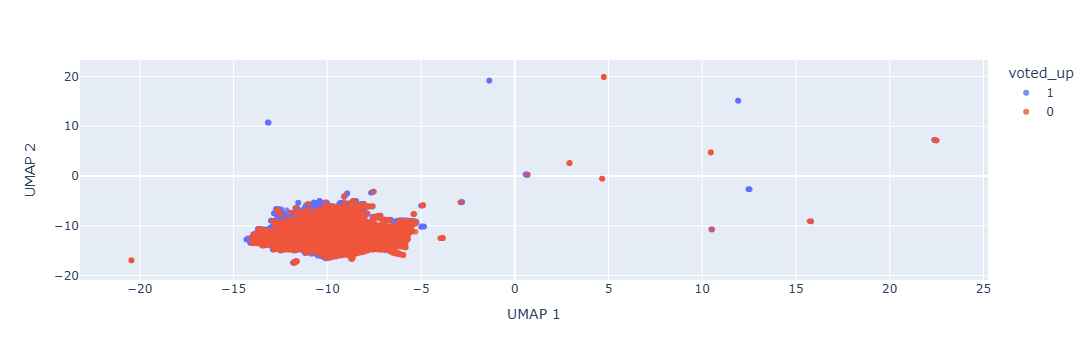

In [30]:
umap_bge_m3_proj = px.scatter(umap_bge_m3_df, x = "UMAP 1", y = "UMAP 2", color = "voted_up", opacity = 0.8)
umap_bge_m3_proj.show()

In [35]:
umap_bge_m3 = UMAP(n_components = 3, n_neighbors = 30, metric = "cosine",
                  precomputed_knn = (knn_indices, knn_distances), random_state = 8).fit_transform(X_embedding_normalized)

In [36]:
umap_bge_m3_df = pd.DataFrame(umap_bge_m3, columns = ["UMAP 1", "UMAP 2", "UMAP 3"])
umap_bge_m3_df["voted_up"] = Y_bge_m3.astype("str")

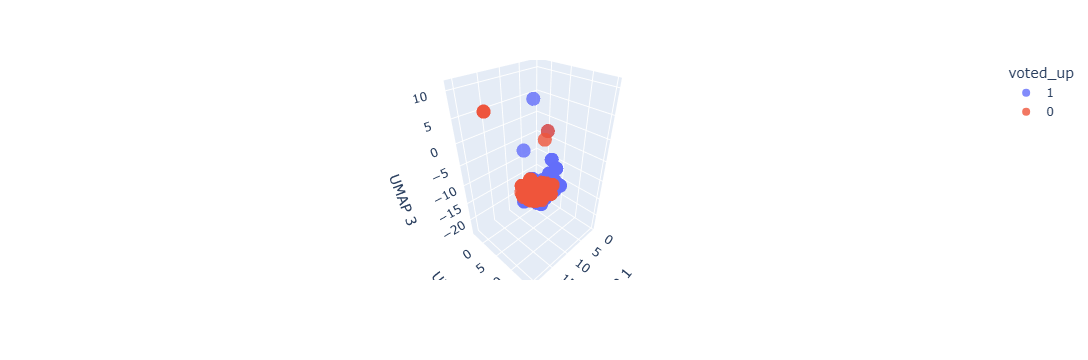

In [39]:
umap_bge_m3_proj = px.scatter_3d(umap_bge_m3_df.iloc[:10000,:], x = "UMAP 1", y = "UMAP 2", z = "UMAP 3", color = "voted_up", opacity = 0.8)
umap_bge_m3_proj.show()

In [40]:
np.savez("umap_bge_m3_df.npz", **umap_bge_m3_df.to_dict(orient = "list")) # save umap dataframe 

## III. B. BGE-M3 Utilizing Cosine Distance for Feature Engineering 

In [56]:
knn_distances.shape

(544744, 30)

In [51]:
knn_distances[0]

array([0.8058009 , 0.79160315, 0.7750061 , 0.7743873 , 0.76361024,
       0.7633464 , 0.75931865, 0.7564776 , 0.75547385, 0.75529104,
       0.7549822 , 0.7533303 , 0.7525611 , 0.7521482 , 0.7513377 ,
       0.7508252 , 0.75032115, 0.7497567 , 0.7485769 , 0.7483784 ,
       0.74617416, 0.74553466, 0.74543005, 0.7451738 , 0.7448079 ,
       0.74405974, 0.7435518 , 0.7432047 , 0.74254346, 0.74234945],
      dtype=float32)

In [52]:
knn_indices[0]

array([511625, 200112, 520838, 513744, 443832, 517091, 302257, 302249,
        91169, 120901, 227818, 517135, 257732, 520891, 488329, 472332,
        27565, 284710, 491841, 227805,  71964, 503054,  75572, 302244,
       366702, 423311,   9919, 114361, 538291, 229677], dtype=int32)

In [67]:
Y_bge_m3[knn_indices][0]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1])

In [96]:
print(knn_distances.min())

0.36814344


In [97]:
print(knn_distances.max())

1.0000005


We can use target encoding with the knn_indices, as well as utilizing the knn_distances aggregates for our engineered features.

---------------------------------------------------------
## III. C. Finetuned BGE-small Training Implementation Plan

- 80/10/10 stratified split, holdout validation (use val set to ensure no leakage during HNSW indexing)
- Finetune BGE-small-en-v1.5 using priority on the first and last tokens and BatchAllTripletLoss on the training set 
- Approx. KNN with HNSW (represent embeddings with distance aggregates with target encoding)
- Get positive / negative word count with Class-based TfidfVectorizer  (utilizing training dictionary only)
- Add Engineered Features
- Categorical Classifier
- Fine-tune the model by adjusting threshold / weights

---------------------------------------------------------------------------------------

### III. C. Training with finetuned BGE-small Embedding Model

#### Note: Finetuning process is found in my Google Colab Notebook for the interest of time. We will be using the embeddings that were created after the finetuning process.

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier # Faster than RF
from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, PrecisionRecallDisplay, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import scipy.sparse as sp
import optuna
import shap

# SVC is avoided due to the high-cardinality of the dataset
# CategoricalNB is avoided due to floating datatype of the distances

In [126]:
X_bge_m3_with_extra_features.shape

(544744, 1027)

In [127]:
indices = np.arange(len(Y_bge_m3)) # index splitting is faster

train_idx, test_idx = train_test_split(indices, test_size = 0.2, stratify = Y_bge_m3, random_state = 8)
val_idx, test_idx = train_test_split(test_idx, test_size = 0.5, stratify = Y_bge_m3[test_idx], random_state = 8)

X_train = X_bge_m3_with_extra_features[train_idx]
X_val = X_bge_m3_with_extra_features[val_idx]
X_test = X_bge_m3_with_extra_features[test_idx]
y_train = Y_bge_m3[train_idx]
y_val = Y_bge_m3[val_idx]
y_test = Y_bge_m3[test_idx]

In [6]:
X_train_extra_features_only = np.load("train_test_bge_m3.npz", mmap_mode = "r")["X_train"]
X_val_extra_features_only = np.load("train_test_bge_m3.npz", mmap_mode = "r")["X_val"]
X_test_extra_features_only = np.load("train_test_bge_m3.npz", mmap_mode = "r")["X_test"]

X_train_extra_features_only = X_train_extra_features_only[: ,-3:] # keep only the 3 extra features
X_val_extra_features_only = X_val_extra_features_only[: ,-3:]
X_test_extra_features_only = X_test_extra_features_only[: ,-3:]



X_train = np.load("X_train_embeddings.npy", mmap_mode = "r")
y_train = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_train"]
X_val = np.load("X_val_embeddings.npy", mmap_mode = "r")
y_val = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_val"]
X_test = np.load("X_test_embeddings.npy", mmap_mode = "r")
y_test = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_test"]

X_train.shape

(435795, 384)

In [7]:
train_idx = np.load("split_indices.npz", mmap_mode = "r")["train_idx"]
val_idx = np.load("split_indices.npz", mmap_mode = "r")["val_idx"]
test_idx = np.load("split_indices.npz", mmap_mode = "r")["test_idx"]

#### Establishing baseline - OOTB LightGBM on the finetuned BGE-small embeddings

In [8]:
LGBMClassifier_baseline = LGBMClassifier()
LGBMClassifier_baseline.fit(X_train, y_train)
y_pred_baseline = LGBMClassifier_baseline.predict(X_test)
print(f1_score(y_test, y_pred_baseline, average = "macro"))

[LightGBM] [Info] Number of positive: 329041, number of negative: 106754
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.677935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 435795, number of used features: 384
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.755036 -> initscore=1.125655
[LightGBM] [Info] Start training from score 1.125655
0.9333695575619931


#### Establishing baseline - Balanced Logistic Regression w/ SAGA on the finetuned BGE-small embeddings

In [9]:
LogisticRegression_baseline = LogisticRegression(solver = "saga", class_weight = "balanced")
LogisticRegression_baseline.fit(X_train, y_train)
y_pred_baseline = LogisticRegression_baseline.predict(X_test)
print(f1_score(y_test, y_pred_baseline, average = "macro"))

0.9302330131850665


#### Approx. KNN with HNSW

In [10]:
train_knn_indices, train_knn_distances, X_train_embedding_normalized = create_HNSW_index(X_train, n_neighbors = 30, 
                                                                                         file_title = "train_bge_finetune", ef_construction = 256)
np.savez("HNSW_results_BGE_M3_train.npz",
        train_knn_indices = train_knn_indices,
        train_knn_distances = train_knn_distances,
        X_train_normalized = X_train_embedding_normalized)

Normalizing X_embedding is finished! 

HNSW Initial Indexing is finished! 

Saved HNSW Initial Indexing! 

Batch 0 - 10000 start...
Done querying!
Batch 10000 - 20000 start...
Done querying!
Batch 20000 - 30000 start...
Done querying!
Batch 30000 - 40000 start...
Done querying!
Batch 40000 - 50000 start...
Done querying!
Batch 50000 - 60000 start...
Done querying!
Batch 60000 - 70000 start...
Done querying!
Batch 70000 - 80000 start...
Done querying!
Batch 80000 - 90000 start...
Done querying!
Batch 90000 - 100000 start...
Done querying!
Batch 100000 - 110000 start...
Done querying!
Batch 110000 - 120000 start...
Done querying!
Batch 120000 - 130000 start...
Done querying!
Batch 130000 - 140000 start...
Done querying!
Batch 140000 - 150000 start...
Done querying!
Batch 150000 - 160000 start...
Done querying!
Batch 160000 - 170000 start...
Done querying!
Batch 170000 - 180000 start...
Done querying!
Batch 180000 - 190000 start...
Done querying!
Batch 190000 - 200000 start...
Done queryi

In [85]:
train_knn_indices = np.load("HNSW_results_BGE_M3_train.npz", mmap_mode = "r")["train_knn_indices"]
train_knn_distances = np.load("HNSW_results_BGE_M3_train.npz", mmap_mode = "r")["train_knn_distances"]

In [11]:
train_knn_mean_distances = train_knn_distances.mean(axis = 1) # how tight the neighborhood is (bigger implies being an outlier review)
train_knn_std_distances = train_knn_distances.std(axis = 1) # how consistent the review is with its neighbors (bigger implies inconsistency)
train_knn_target_encoding_mean = (y_train[train_knn_indices]).mean(axis = 1) # y_train data only, check the average sentiment of the neighborhood (higher implies positive)
train_knn_target_encoding_std = y_train[train_knn_indices].std(axis = 1) # y_train data only, check the sentiment consistency of the neighborhood

In [14]:
train_knn_target_encoding_mean

array([0.        , 0.96666667, 0.03333333, ..., 0.        , 0.        ,
       0.7       ], shape=(435795,))

**We now have distance aggregates and target encoded features from HNSW.**

#### Getting Positive and Negative Words with Class-based TF-IDF 

In [15]:
train_idx = np.load("split_indices.npz", mmap_mode = "r")["train_idx"]
val_idx = np.load("split_indices.npz", mmap_mode = "r")["val_idx"]
test_idx = np.load("split_indices.npz", mmap_mode = "r")["test_idx"]

In [12]:
review_text_resampled = pd.read_parquet("review_text_resampled.parquet")

In [13]:
train_review_text = review_text_resampled.iloc[train_idx][["review_text", "voted_up"]].copy()
train_review_text.to_parquet("train_review_text.parquet")
train_review_text.head()

,review_text,voted_up
472403,"I'm sorry, but I didn't like this game. I real...",False
412409,Game hunters fr cooked on this,True
82313,I found this VN extremely boring. There was ba...,False
410343,you're not alone if you thought batds was shal...,True
109272,A very strange/unique 3D RTS I've remembered s...,True


In [14]:
train_review_text = pd.read_parquet("train_review_text.parquet")
train_review_text_corpus = train_review_text.copy()
del train_review_text
train_review_text_corpus.reset_index(drop = True, inplace = True)

In [72]:
from joblib import dump, load

In [19]:
vectorizer = CountVectorizer(max_df = 0.95, min_df = int(max(min(0.0001*len(train_review_text_corpus), 50), 2)), ngram_range = (1,2)) 
top_word_dictionary = vectorizer.fit(train_review_text_corpus["review_text"]).get_feature_names_out()
dump(vectorizer, "vectorizer.joblib")

['vectorizer.joblib']

In [20]:
len(top_word_dictionary)

89091

In [21]:
top_word_dictionary[0:1000]

array(['00', '00 for', '000', '000 000', '000 completely', '000 free',
       '000 games', '000 hours', '01', '02', '03', '04', '05', '06', '07',
       '08', '09', '10', '10 00', '10 000', '10 10', '10 11', '10 12',
       '10 15', '10 20', '10 30', '10 99', '10 also', '10 amazing',
       '10 and', '10 art', '10 as', '10 at', '10 author', '10 because',
       '10 best', '10 bucks', '10 but', '10 buy', '10 can', '10 could',
       '10 definitely', '10 different', '10 dlc', '10 do', '10 dollars',
       '10 don', '10 edit', '10 euros', '10 even', '10 experience',
       '10 feet', '10 for', '10 fps', '10 from', '10 fun', '10 game',
       '10 gameplay', '10 games', '10 get', '10 give', '10 good',
       '10 graphics', '10 great', '10 h1', '10 h3', '10 have',
       '10 highly', '10 hope', '10 hour', '10 hours', '10 https', '10 if',
       '10 ign', '10 in', '10 is', '10 it', '10 its', '10 just',
       '10 levels', '10 like', '10 love', '10 maybe', '10 min', '10 mins',
       '10 minut

In [15]:
def tf_by_batch(review_text):
    vectorizer = load("vectorizer.joblib")
    batch_size = 50000
    tf_matrix = []
    for i in range(0, len(review_text), batch_size):
        batch = review_text.iloc[i: i + batch_size]
        tf_matrix.append(vectorizer.transform(batch))
        
    return sp.vstack(tf_matrix)

In [16]:
tf_matrix_all = tf_by_batch(train_review_text_corpus["review_text"])
tf_matrix_all.shape

(435795, 89091)

In [24]:
positive_reviews = (train_review_text_corpus["voted_up"] == True).values
negative_reviews = (train_review_text_corpus["voted_up"] == False).values

In [25]:
positive_reviews.shape

(435795,)

In [26]:
positive_review_word_count = np.asarray(tf_matrix_all[positive_reviews].sum(axis=0)).flatten()
negative_review_word_count = np.asarray(tf_matrix_all[negative_reviews].sum(axis=0)).flatten()

In [27]:
tf_per_class = sp.csr_matrix(np.vstack([positive_review_word_count, negative_review_word_count]))
tf_per_class.shape

(2, 89091)

In [28]:
C_tfidf_matrix = ClassTfidfTransformer(reduce_frequent_words = True).fit_transform(tf_per_class)
C_tfidf_matrix.shape

(2, 89091)

In [29]:
positive_word_scores = C_tfidf_matrix[0].toarray().flatten()
negative_word_scores = C_tfidf_matrix[1].toarray().flatten()

positive_word_scores[0:]

array([0.03718695, 0.00946027, 0.04090338, ..., 0.01400934, 0.02075607,
       0.01764163], shape=(89091,))

In [30]:
cross_sentiment_scores = positive_word_scores - negative_word_scores # remove intersections, higher = positive; lower = negative

top_n = int(max(0.05*len(top_word_dictionary), 500)) # can be adjusted, default to 5% of each end

top_positive_idx = np.argsort(cross_sentiment_scores)[-(top_n):]
top_negative_idx = np.argsort(cross_sentiment_scores)[:top_n]
top_positive_words = top_word_dictionary[top_positive_idx]
top_negative_words = top_word_dictionary[top_negative_idx]

In [31]:
np.sort(cross_sentiment_scores)[:top_n]

array([-0.11000822, -0.1075869 , -0.10415821, ..., -0.01377374,
       -0.01377227, -0.01377179], shape=(4454,))

In [32]:
top_negative_words[:1000]

array(['no', 'not worth', 'refund', 'terrible', 'boring', 'waste',
       'unplayable', 'asset', 'not buy', '1001 jigsaw', 'gamers', '1001',
       'worst', 'poor', 'waste of', 'not', 'awful', 'broken', 'do not',
       'defects', 'not recommend', 'garbage', 'the worst', 'poorly',
       'gamers to', 'abandoned', 'pc gamers', 'mobile app', 'jigsaw',
       'for gamers', 'solitaire', 'scam', 'money', 'horrible',
       'waste your', 'at all', 'cannot', 'even', 'not even',
       'url developed', 'nothing', 'don buy', 'bad', 'not fun', 'no way',
       'worse', 'trash', 'there no', 'asset flip', 'app',
       'cannot recommend', 'low quality', 'the defects', 'impossible to',
       'unity com', 'assetstore unity', 'https assetstore',
       'com packages', 'doesn', 'just not', 'poor quality', 'don waste',
       'technical defects', 'why', 'mobile', 'unfortunately',
       'assetstore', 'your money', 'just', '000 games', 'defects push',
       'basic minimum', 'uninstalling', 'refunded',

In [33]:
np.sort(cross_sentiment_scores)[-(top_n):]

array([0.01320172, 0.01320172, 0.01320197, ..., 0.09559066, 0.10182188,
       0.10951482], shape=(4454,))

In [34]:
top_positive_words[:1000]

array(['strategies the', 'enthusiasts and', 'long after',
       'started playing', 'buy for', 'will need', 'challenging with',
       'happen next', 'and tense', 'get quite', 'unique style', 'at good',
       'ramps up', 'check if', 'visuals are', 'helps to', 'the vibe',
       'good bit', 'of genres', 'good pace', 'tear', 'varying', 'tale of',
       'addiction', 'quite enjoyed', 'are charming', 'best experience',
       'be difficult', 'backstories', 'recommend everyone', 'done great',
       'really gives', 'capturing the', 'builds on', 'are satisfying',
       'visually the', 'pressure', 'and bosses', 'everything works',
       'and narrative', 'definitely enjoyed', 'or sequel',
       'shines through', 'adrenaline pumping', 'amazing atmosphere',
       'relaxing gameplay', 'especially love', 'complexity to',
       'classic rpg', 'chill out', 'itself too', 'customization',
       'worry about', 'first time', 'pokemon', 'the pain',
       'the simplicity', 'and finding', 'better l

In [35]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [36]:
def ngram_stop_word_checker(word_array):
    checker_array = []
    for word in word_array:
        ngram = word.split()
        
        all_stop_words = all(word in ENGLISH_STOP_WORDS for word in ngram)

        if all_stop_words:
            checker_array.append(False) 
        else:
            checker_array.append(True)  
            
    return checker_array

In [37]:
filter_positive_words = ngram_stop_word_checker(top_positive_words)
filter_negative_words = ngram_stop_word_checker(top_negative_words)

In [38]:
top_positive_words_filtered = top_positive_words[filter_positive_words]
top_negative_words_filtered = top_negative_words[filter_negative_words]

In [39]:
top_negative_words_filtered

array(['not worth', 'refund', 'terrible', ..., 'to manually',
       'wasted potential', 'didnt'], shape=(4015,), dtype=object)

In [40]:
top_positive_idx_filtered = top_positive_idx[filter_positive_words]
top_negative_idx_filtered = top_negative_idx[filter_negative_words]

In [41]:
top_negative_idx_filtered

array([50648, 61385, 71420, ..., 78841, 83935, 19841], shape=(4015,))

In [17]:
top_positive_idx_filtered = np.load("train_filtered_top_words.npz")["top_positive_idx_filtered"]
top_negative_idx_filtered = np.load("train_filtered_top_words.npz")["top_negative_idx_filtered"]

In [18]:
train_positive_words_count = np.asarray(tf_matrix_all[ : , top_positive_idx_filtered].sum(axis=1)).flatten()
train_negative_words_count = np.asarray(tf_matrix_all[ : , top_negative_idx_filtered].sum(axis=1)).flatten()

In [19]:
train_positive_words_count.shape

(435795,)

In [44]:
np.savez("train_filtered_top_words.npz",
         positive_word_scores = positive_word_scores,
         negative_word_scores = negative_word_scores,
         cross_sentiment_scores = cross_sentiment_scores,
         top_positive_words_filtered = top_positive_words_filtered, 
         top_negative_words_filtered = top_negative_words_filtered,
         top_positive_idx_filtered = top_positive_idx_filtered,
         top_negative_idx_filtered = top_negative_idx_filtered,
         train_positive_words_count = train_positive_words_count,
         train_negative_words_count = train_negative_words_count)

**We now have our engineered positive and negative word count per review.**

#### Add Engineered Features (and only use these for the model)

We now have:
- 2 knn_distance aggregates from HNSW
- 2 target encoded features still from HNSW
- 2 features counting positive and negative words in a review
- 3 features relevant to a gamer's review

In [20]:
X_train_engineered_features = np.empty((train_knn_distances.shape[0], 9), # keep only the engineered columns
                                      dtype = train_knn_distances.dtype)

In [21]:
X_train_engineered_features[:, 0] = train_knn_mean_distances
X_train_engineered_features[:, 1] = train_knn_std_distances
X_train_engineered_features[:, 2] = train_knn_target_encoding_mean 
X_train_engineered_features[:, 3] = train_knn_target_encoding_std
X_train_engineered_features[:, 4] = train_positive_words_count
X_train_engineered_features[:, 5] = train_negative_words_count
X_train_engineered_features[:, 6:] = X_train_extra_features_only


X_train_engineered_features.shape

(435795, 9)

In [22]:
np.save("X_train_engineered_features_BGE_finetuned.npy", X_train_engineered_features)

#### Extra Step: Separate preparation of the Validation Set to prevent leakage

In [23]:
def HNSW_query(X_embedding, n_neighbors, file_name): # default is 30
    
    num_elements, dim = X_embedding.shape

    norms = np.linalg.norm(X_embedding, axis = 1, keepdims = True)
    norms[norms == 0] = 1.0
    X_embedding_normalized = X_embedding / norms
    print("Normalizing X_embedding is finished! \n")

    hnsw_index = hnswlib.Index(space = "cosine", dim = dim)
    hnsw_index.load_index(f"{file_name}_hnsw_index.bin") # get original hnsw_index from creation

    knn_indices = np.empty((num_elements, n_neighbors), dtype = np.int32)
    knn_distances = np.empty((num_elements, n_neighbors), dtype = np.float32)
    
    batch_size = 10000
    for i in range(0, num_elements, batch_size):
        end = min(i + batch_size, num_elements)
        print(f"Batch {i} - {end} start...")
        batch_data = X_embedding_normalized[i:end]
    
        indices, distances = hnsw_index.knn_query(batch_data, k = n_neighbors + 1) # will be used during val/test
        print("Done querying!")
    
        knn_indices[i:end] = indices[: , 1:].astype(np.int32)
        knn_distances[i:end] = (1.0 - distances[:, 1:]).astype(np.float32)

    print("\n Finished creating indices and distances!")
    return knn_indices, knn_distances

In [24]:
val_knn_indices, val_knn_distances = HNSW_query(X_val[:,:-3], 30, file_name = "train_bge_finetune")
np.savez("HNSW_results_BGE_M3_val.npz",
        val_knn_indices = val_knn_indices,
        val_knn_distances = val_knn_distances)

Normalizing X_embedding is finished! 

Batch 0 - 10000 start...
Done querying!
Batch 10000 - 20000 start...
Done querying!
Batch 20000 - 30000 start...
Done querying!
Batch 30000 - 40000 start...
Done querying!
Batch 40000 - 50000 start...
Done querying!
Batch 50000 - 54474 start...
Done querying!

 Finished creating indices and distances!


In [25]:
val_knn_mean_distances = val_knn_distances.mean(axis = 1) # how tight the neighborhood is (bigger implies being an outlier review)
val_knn_std_distances = val_knn_distances.std(axis = 1) # how consistent the review is with its neighbors (bigger implies inconsistency)
val_knn_target_encoding_mean = (y_train[val_knn_indices]).mean(axis = 1) # y_train data only, check the average sentiment of the neighborhood (higher implies positive)
val_knn_target_encoding_std = y_train[val_knn_indices].std(axis = 1) # y_train data only, check the sentiment consistency of the neighborhood

In [51]:
review_text_resampled = pd.read_parquet("review_text_resampled.parquet")

In [26]:
val_review_text = review_text_resampled.iloc[val_idx][["review_text", "voted_up"]].copy()
val_review_text.to_parquet("val_review_text.parquet")
val_review_text.head()

,review_text,voted_up
423313,Add Münster,True
491173,Construction Simulator 2015: St. John’s Hospit...,True
351705,The game is fairly interestin' from the get go...,True
430886,"Really cool addon with new mecanics, more tile...",True
396614,Unfortunately it turned out to be really reall...,False


In [27]:
val_review_text = pd.read_parquet("val_review_text.parquet")
val_review_text_corpus = val_review_text.copy()
del val_review_text
val_review_text_corpus.reset_index(drop = True, inplace = True)
gc.collect()

102

In [28]:
tf_matrix_all = tf_by_batch(val_review_text_corpus["review_text"])
tf_matrix_all.shape

(54474, 89091)

In [29]:
val_positive_words_count = np.asarray(tf_matrix_all[ : , top_positive_idx_filtered].sum(axis=1)).flatten()
val_negative_words_count = np.asarray(tf_matrix_all[ : , top_negative_idx_filtered].sum(axis=1)).flatten()

In [30]:
val_positive_words_count.shape

(54474,)

In [31]:
np.savez("val_c_tfidf_results.npz",
        val_positive_words_count = val_positive_words_count,
        val_negative_words_count = val_negative_words_count)

In [32]:
X_val_engineered_features = np.empty((val_knn_distances.shape[0], 9), # keep only the engineered columns
                                      dtype = val_knn_distances.dtype)

In [33]:
X_val_engineered_features[:, 0] = val_knn_mean_distances
X_val_engineered_features[:, 1] = val_knn_std_distances
X_val_engineered_features[:, 2] = val_knn_target_encoding_mean 
X_val_engineered_features[:, 3] = val_knn_target_encoding_std
X_val_engineered_features[:, 4] = val_positive_words_count
X_val_engineered_features[:, 5] = val_negative_words_count
X_val_engineered_features[:, 6:] = X_val_extra_features_only


X_val_engineered_features.shape

(54474, 9)

In [34]:
np.save("X_val_engineered_features_bge_finetuned.npy", X_val_engineered_features)

#### Categorical Classifier

In [35]:
X_train = np.load("X_train_engineered_features_bge_finetuned.npy", mmap_mode = "r") # renaming for convention
y_train = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_train"]
X_val = np.load("X_val_engineered_features_bge_finetuned.npy", mmap_mode = "r")
y_val = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_val"]

In [36]:
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer

**Note: We use <u>holdout validation</u> because of HNSW indexing causing leakage as it connects the whole training set.**
Constantly creating indices on 300k samples is also very time-consuming. Querying, however, is relatively fast.

In [37]:
multiple_transforms = Pipeline([
    ("log1p",FunctionTransformer(np.log1p)), # helps with skewness (ex. author_playtime_at_review)
    ("minmax", MinMaxScaler()) # all knn_distances are between 0 and 1. Since we will not scale the distances we will adjust to MinMaxScaler
])

scale_extra_features = ColumnTransformer([
        ("scaler", multiple_transforms, slice(-5, None))
    ], remainder = "passthrough") # scale pos/neg word count and extra features, keep knn_distances and aggregates

In [38]:
def objective_predict_array(model_name):
    def objective_predict(trial):
        # LGBM, Hist, XGB, MLP, LogReg, GaussianNB 
        # All static parameters going forward will be under trial.categorical under one choice so that it will be passed in the best params.
        
        if model_name == "MLPClassifier":
            num_layers = trial.suggest_int("num_layers_mlp",2,3)
            layer = []
            nth_layer = 1
            
            while nth_layer <= num_layers:
                num_perceptron = trial.suggest_categorical(f"num_perceptron_layer{nth_layer}_mlp",[64,32,16,8])
                layer.append(num_perceptron)
                nth_layer += 1

            param = {
            "hidden_layer_sizes" : tuple(layer),
            "activation" : trial.suggest_categorical("activation_mlp", ["relu"]), # removing to increase speed: identity, logistic, tanh 
            "solver" : trial.suggest_categorical("solver_mlp", ["adam"]), # "lbfgs" is slow, "sgd" is fast but adam is preferred  
            "alpha" : trial.suggest_float("alpha_mlp", 1e-5, 10, log = True),
            "max_iter": trial.suggest_categorical("max_iter_mlp", [1000]), 
            "early_stopping" : trial.suggest_categorical("early_stopping_mlp", [True]),
            "n_iter_no_change" : trial.suggest_categorical("n_iter_no_change_mlp", [20]),    
            "batch_size" : trial.suggest_categorical("batch_size_mlp", [2048]), # for speeding up training
            "tol" : trial.suggest_categorical("tol_mlp", [1e-3, 1e-4]), # for speeding up training
            "random_state" : trial.suggest_categorical("random_state_mlp", [8])
            }
            if param["solver"] == "sgd":
                param["learning_rate"] = trial.suggest_categorical("learning_rate_mlp",["constant", "invscaling", "adaptive"])
                param["learning_rate_init"] = trial.suggest_float("learning_rate_init_mlp", 1e-3, 1e-1, log = True)
                if param["learning_rate"] == "invscaling":
                    param["power_t"] = trial.suggest_float("power_t_mlp", 0.1, 1)
                param["momentum"] = trial.suggest_float("momentum_mlp", 0, 1)
            elif param["solver"] == "adam":
                param["learning_rate_init"] = trial.suggest_float("learning_rate_init_mlp", 1e-3, 1e-2, log = True)
                param["beta_1"] = trial.suggest_float("beta_1_mlp", 0, 0.9999999)
                param["beta_2"] = trial.suggest_float("beta_2_mlp", 0, 0.9999999)
                param["epsilon"] = trial.suggest_float("epsilon_mlp", 1e-10, 1e-6, log = True)

        #----------------------------------------------------------------------------------------------------------------

        elif model_name == "HistGradientBoostingClassifier":
            param = {
                "learning_rate" : trial.suggest_float("learning_rate_hist", 1e-2, 0.3, log = True),
                "max_iter": trial.suggest_categorical("max_iter_hist", [1000]), # early stopping is enabled
                "max_leaf_nodes": trial.suggest_int("max_leaf_nodes_hist", 31, 63), 
                "min_samples_leaf" : trial.suggest_int("min_samples_leaf_hist", 500, 2500), # 1% - 5% of sample
                "l2_regularization" : trial.suggest_float("l2_regularization_hist", 1e-5, 10, log = True),
                "max_features" : trial.suggest_float("max_features_hist", 0.7, 1),
                "categorical_features" : trial.suggest_categorical("categorical_features_hist", [None]),
                "n_iter_no_change" : trial.suggest_categorical("n_iter_no_change_hist", [10]),
                "early_stopping" : trial.suggest_categorical("early_stopping_hist", [True]),
                "random_state" : trial.suggest_categorical("random_state_hist", [8])            
                }
                 
            class_weight_positive = trial.suggest_float("class_weight_positive_hist", 0.25, 0.6) # scale_pos_weight
            param["class_weight"] = {0 : 1, 1 : class_weight_positive}
        
        #----------------------------------------------------------------------------------------------------------------

        elif model_name == "XGBClassifier":
            param = {
                "objective" : trial.suggest_categorical("objective_xgb",["binary:logistic"]),
                "eval_metric" : trial.suggest_categorical("eval_metric_xgb",["logloss"]),
                #"n_estimators" : trial.suggest_categorical("n_estimators_xgb", [1000]), # using xgb.train for faster training
                "learning_rate" : trial.suggest_float("learning_rate_xgb", 1e-3, 0.3, log = True), 
                "max_depth" : trial.suggest_int("max_depth_xgb", 5, 10), 
                "min_child_weight" : trial.suggest_float("min_child_weight_xgb", 20, 250), 
                "subsample" : trial.suggest_float("subsample_xgb", 0.6, 0.9),
                "colsample_bytree": trial.suggest_categorical("colsample_bytree_xgb", [1]), # a.k.a. max features
                #"colsample_bylevel": trial.suggest_float("colsample_bylevel_xgb", 0.6, 0.9),
                #"colsample_bynode": trial.suggest_float("colsample_bynode_xgb", 0.6, 0.9),
                "lambda": trial.suggest_float("lambda_xgb", 1, 20),
                "alpha": trial.suggest_float("alpha_xgb", 1e-6, 10, log = True),
                "gamma": trial.suggest_float("gamma_xgb", 0, 5),
                #"grow_policy": trial.suggest_categorical("grow_policy_xgb", ["depthwise", "lossguide"]),
                "tree_method" : trial.suggest_categorical("tree_method_xgb",["hist"]),
                "scale_pos_weight" : trial.suggest_float("scale_pos_weight_xgb", # usual is total negative / total positive for imbalanced sets
                                                 0.25, 0.6),
                #"early_stopping_rounds" : trial.suggest_categorical("early_stopping_rounds_xgb",[30]), # using xgb.train for faster training
                "device" : trial.suggest_categorical("device_xgb", ["cpu"]),
                "n_jobs" : trial.suggest_categorical("n_jobs_xgb", [-1]),
                "verbosity" : trial.suggest_categorical("verbosity_xgb", [0]),
                "random_state" : trial.suggest_categorical("random_state_xgb", [8])
            }

       #----------------------------------------------------------------------------------------------------------------
            
        elif model_name == "LGBMClassifier":
            param = {
                "objective" : trial.suggest_categorical("objective_lgbm",["binary"]),
                "metric" : trial.suggest_categorical("metric_lgbm",["binary_logloss"]),
                #"n_estimators" : trial.suggest_categorical("n_estimators_lgbm", [1000]), # using lgbm.train for faster training
                "learning_rate" : trial.suggest_float("learning_rate_lgbm", 1e-3, 0.3, log = True), 
                "max_depth" : trial.suggest_int("max_depth_lgbm", 5, 10),
                "min_child_weight" : trial.suggest_float("min_child_weight_lgbm", 0.1, 10), # a.k.a. min_sum_hessian_in_leaf
                "min_child_samples" : trial.suggest_int("min_child_samples_lgbm", 20, 250), # a.k.a. min_data_in_leaf
                "min_data_in_bin" : trial.suggest_int("min_data_in_bin_lgbm", 50, 500),
                "max_bin" : trial.suggest_int("max_bin_lgbm", 255, 280),
                "subsample" : trial.suggest_float("subsample_lgbm", 0.6, 0.9),
                "colsample_bytree": trial.suggest_categorical("colsample_bytree_lgbm", [1]), # a.k.a max features
                #"colsample_bylevel": trial.suggest_float("colsample_bylevel_lgbm", 0.6, 0.9),
                #"colsample_bynode": trial.suggest_float("colsample_bynode_lgbm", 0.6, 0.9),
                "reg_lambda": trial.suggest_float("reg_lambda_lgbm", 1, 10),
                "reg_alpha": trial.suggest_float("reg_alpha_lgbm", 1e-3, 10, log = True),
                "min_gain_to_split": trial.suggest_float("min_gain_to_split_lgbm", 0, 5), # a.k.a. gamma
                #"is_unbalance": trial.suggest_categorical("is_unbalance_lgbm", [True]), # alternative to scale_pos_weight
                "scale_pos_weight" : trial.suggest_float("scale_pos_weight_lgbm", # usual is total negative / total positive for imbalanced sets
                                                   0.25, 0.6),
                #"early_stopping_rounds" : trial.suggest_categorical("early_stopping_rounds_lgbm", [30]), # using lgbm.train for faster training
                "device" : trial.suggest_categorical("device_lgbm", ["cpu"]),
                "n_jobs" : trial.suggest_categorical("n_jobs_lgbm", [-1]),
                "verbosity" : trial.suggest_categorical("verbosity_lgbm", [-1]),
                "random_state" : trial.suggest_categorical("random_state_lgbm", [8])
                
            }
        
            num_leaves_ceiling = min(2**(param["max_depth"]), 256)
            param["num_leaves"] = trial.suggest_int("num_leaves_lgbm", 31, num_leaves_ceiling) # ceiling shoud be less than 2^max_depth

         #----------------------------------------------------------------------------------------------------------------

        elif model_name == "LogisticRegression":
            param = {
                "C" : trial.suggest_float("C_logreg", 1e-3, 100, log = True),
                "solver" : trial.suggest_categorical("solver_logreg", 
                                                     ["lbfgs", "saga", "newton-cholesky"]), # newton-cg, "liblinear" for smaller samples
                #"class_weight" : trial.suggest_categorical("class_weight_logreg", ["balanced"]),
                "max_iter" : trial.suggest_categorical("max_iter_logreg", [1000]),
                }
            if param["solver"] == "saga":
                param["l1_ratio"] = trial.suggest_float("l1_ratio_saga_logreg", 0, 1)
                param["random_state"] = 8
            elif param["solver"] == "liblinear":
                param["l1_ratio"] = trial.suggest_categorical("l1_ratio_liblinear_logreg", [0, 1])
                param["random_state"] = 8
        
            class_weight_positive = trial.suggest_float("class_weight_positive_logreg", 0.25, 0.6) # scale_pos_weight
            param["class_weight"] = {0 : 1, 1 : class_weight_positive}

         #----------------------------------------------------------------------------------------------------------------
          
        elif model_name == "GaussianNB":
            param = {
                "var_smoothing" : trial.suggest_float("var_smoothing_Gnb", 1e-9, 1, log = True)
                }
            
         #----------------------------------------------------------------------------------------------------------------

#        stratified_kf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 8)
#        score = []        
        

#        for fold, (train_idx, val_idx) in enumerate(stratified_kf.split(X_train, y_train)):
#            X_train_fold = X_train[train_idx]
#            X_val_fold = X_train[val_idx]
#            y_train_fold = y_train[train_idx]
#            y_val_fold = y_train[val_idx]

        
        # removing indentation of for-loop since we are doing holdout validation    
        if model_name == "XGBClassifier": # no scaling needed
            dtrain = xgb.DMatrix(X_train, label = y_train)
            dval = xgb.DMatrix(X_val, label = y_val)
            xgb_classifier = xgb.train(param,
                dtrain,
                num_boost_round = 2000,
                early_stopping_rounds = 30,
                evals = [(dval, "val")],
                verbose_eval = False
            )
            y_pred_fold = (xgb_classifier.predict(dval) >= 0.5).astype(int) # 0.5 threshold, binary class 

        elif model_name == "LGBMClassifier": # no scaling needed
            dtrain = lgbm.Dataset(X_train, label = y_train)
            dval = lgbm.Dataset(X_val, label = y_val, reference = dtrain)
            lgbm_classifier = lgbm.train(param,
                dtrain,
                num_boost_round = 2000,                         
                valid_sets = [dval],
                callbacks = [lgbm.early_stopping(stopping_rounds = 30, verbose = False),
                             lgbm.log_evaluation(period = -1)]
            )
            y_pred_fold = (lgbm_classifier.predict(X_val) >= 0.5).astype(int) # 0.5 threshold, binary class 
            
        else:
            pipeline = Pipeline([
                ("scale_extra_features", scale_extra_features), # HistGradientBoostingClassifier need no scaling, but cannot fit eval_set
                ("classifier", globals()[model_name](**param)) 
            ])
               
            pipeline.fit(X_train, y_train)
            y_pred_fold = pipeline.predict(X_val)

        f1_score_fold = f1_score(y_val, y_pred_fold, average = "macro")
        # score.append(f1_score_fold)

        # trial.report(np.mean(score), step = fold)

        #if trial.should_prune():
        #    raise optuna.exceptions.TrialPruned()

        return f1_score_fold # np.mean(score)
    return objective_predict

In [39]:
for model_name in ["LGBMClassifier", "HistGradientBoostingClassifier", "XGBClassifier",
                  "MLPClassifier", "LogisticRegression", "GaussianNB"]:
    study_classification = optuna.create_study(
        direction = "maximize", 
        study_name = f"steam_BGE_M3_classify_{model_name}_bge_finetuned_final", 
        sampler = optuna.samplers.TPESampler(seed = 8),
#        pruner = optuna.pruners.MedianPruner(n_warmup_steps = 3, n_startup_trials = 33), # using holdout validation now, so pruner is not needed
        storage = "sqlite:///steam_BGE_M3_classification.db",
        load_if_exists = True)
    
    completed_trials = len(study_classification.get_trials(states = (optuna.trial.TrialState.COMPLETE,)))
    pruned_trials = len(study_classification.get_trials(states = (optuna.trial.TrialState.PRUNED,)))
    if completed_trials + pruned_trials >= 100: # prevents adding more trials after adjusting objective
        print("-" * 50)
        print(f"\n{model_name} has already finished all trials! Moving to next model...")
        print(f"{model_name} best score: {study_classification.best_value:.4f}")
        print(f"{model_name} best params: {study_classification.best_params}\n")
        print("-" * 50)
        continue
    
    study_classification.optimize(
        objective_predict_array(model_name), 
        n_trials = 100,
        show_progress_bar = True)
    print("-" * 30)
    print(f"\n{model_name} best score: {study_classification.best_value:.4f}")
    print(f"{model_name} best params: {study_classification.best_params}\n")
    print("-" * 30)

[I 2026-05-27 17:32:09,718] A new study created in RDB with name: steam_BGE_M3_classify_LGBMClassifier_bge_finetuned_final


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-27 17:32:14,341] Trial 0 finished with value: 0.9318487804659499 and parameters: {'objective_lgbm': 'binary', 'metric_lgbm': 'binary_logloss', 'learning_rate_lgbm': 0.1457439508100878, 'max_depth_lgbm': 10, 'min_child_weight_lgbm': 8.705025948117807, 'min_child_samples_lgbm': 142, 'min_data_in_bin_lgbm': 154, 'max_bin_lgbm': 255, 'subsample_lgbm': 0.7291406454877472, 'colsample_bytree_lgbm': 1, 'reg_lambda_lgbm': 4.621162240336283, 'reg_alpha_lgbm': 0.12322495987505251, 'min_gain_to_split_lgbm': 2.391958979012012, 'scale_pos_weight_lgbm': 0.44437476583781566, 'device_lgbm': 'cpu', 'n_jobs_lgbm': -1, 'verbosity_lgbm': -1, 'random_state_lgbm': 8, 'num_leaves_lgbm': 153}. Best is trial 0 with value: 0.9318487804659499.
[I 2026-05-27 17:32:15,821] Trial 1 finished with value: 0.9276470220530285 and parameters: {'objective_lgbm': 'binary', 'metric_lgbm': 'binary_logloss', 'learning_rate_lgbm': 0.07670622375141321, 'max_depth_lgbm': 9, 'min_child_weight_lgbm': 6.234852751424052, '

[I 2026-05-27 18:02:32,101] A new study created in RDB with name: steam_BGE_M3_classify_HistGradientBoostingClassifier_bge_finetuned_final


[I 2026-05-27 18:02:32,016] Trial 99 finished with value: 0.933857022344782 and parameters: {'objective_lgbm': 'binary', 'metric_lgbm': 'binary_logloss', 'learning_rate_lgbm': 0.003584678903065625, 'max_depth_lgbm': 9, 'min_child_weight_lgbm': 6.20117977998337, 'min_child_samples_lgbm': 198, 'min_data_in_bin_lgbm': 230, 'max_bin_lgbm': 266, 'subsample_lgbm': 0.7993618108642844, 'colsample_bytree_lgbm': 1, 'reg_lambda_lgbm': 1.3460287135829825, 'reg_alpha_lgbm': 0.015554826086951997, 'min_gain_to_split_lgbm': 0.8724142011141912, 'scale_pos_weight_lgbm': 0.5659241628567074, 'device_lgbm': 'cpu', 'n_jobs_lgbm': -1, 'verbosity_lgbm': -1, 'random_state_lgbm': 8, 'num_leaves_lgbm': 129}. Best is trial 87 with value: 0.9340865479992455.
------------------------------

LGBMClassifier best score: 0.9341
LGBMClassifier best params: {'objective_lgbm': 'binary', 'metric_lgbm': 'binary_logloss', 'learning_rate_lgbm': 0.005168527951776221, 'max_depth_lgbm': 8, 'min_child_weight_lgbm': 7.505991453456

...

[I 2026-05-27 19:24:00,813] Trial 0 finished with value: 0.9313593830865452 and parameters: {'C_logreg': 23.288794782471303, 'solver_logreg': 'lbfgs', 'max_iter_logreg': 1000, 'class_weight_positive_logreg': 0.33145491479205175}. Best is trial 0 with value: 0.9313593830865452.
[I 2026-05-27 19:24:01,465] Trial 1 finished with value: 0.9329452501642382 and parameters: {'C_logreg': 0.0011402340906886685, 'solver_logreg': 'newton-cholesky', 'max_iter_logreg': 1000, 'class_weight_positive_logreg': 0.4174371285308408}. Best is trial 1 with value: 0.9329452501642382.
[I 2026-05-27 19:24:04,741] Trial 2 finished with value: 0.9326087027717708 and parameters: {'C_logreg': 0.5981117979706079, 'solver_logreg': 'saga', 'max_iter_logreg': 1000, 'l1_ratio_saga_logreg': 0.6196820961034396, 'class_weight_positive_logreg': 0.3991321196666673}. Best is trial 1 with value: 0.9329452501642382.
[I 2026-05-27 19:24:05,615] Trial 3 finished with value: 0.9308198191417639 and parameters: {'C_logreg': 0.02788

[I 2026-05-27 19:28:29,738] A new study created in RDB with name: steam_BGE_M3_classify_GaussianNB_bge_finetuned_final


[I 2026-05-27 19:28:29,676] Trial 99 finished with value: 0.9330171018743811 and parameters: {'C_logreg': 0.1490028555755859, 'solver_logreg': 'newton-cholesky', 'max_iter_logreg': 1000, 'class_weight_positive_logreg': 0.562385005481769}. Best is trial 75 with value: 0.9334301512866774.
------------------------------

LogisticRegression best score: 0.9334
LogisticRegression best params: {'C_logreg': 0.363287283280062, 'solver_logreg': 'newton-cholesky', 'max_iter_logreg': 1000, 'class_weight_positive_logreg': 0.5996623900524208}

------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-27 19:28:29,976] Trial 0 finished with value: 0.9325087696185071 and parameters: {'var_smoothing_Gnb': 0.07258796566465744}. Best is trial 0 with value: 0.9325087696185071.
[I 2026-05-27 19:28:30,241] Trial 1 finished with value: 0.9326519010495742 and parameters: {'var_smoothing_Gnb': 0.5210338816341213}. Best is trial 1 with value: 0.9326519010495742.
[I 2026-05-27 19:28:30,444] Trial 2 finished with value: 0.932267096072926 and parameters: {'var_smoothing_Gnb': 0.06648916239729033}. Best is trial 1 with value: 0.9326519010495742.
[I 2026-05-27 19:28:30,659] Trial 3 finished with value: 0.9252979908659021 and parameters: {'var_smoothing_Gnb': 5.993785875919234e-05}. Best is trial 1 with value: 0.9326519010495742.
[I 2026-05-27 19:28:30,895] Trial 4 finished with value: 0.9251331859515626 and parameters: {'var_smoothing_Gnb': 1.2432399345154932e-07}. Best is trial 1 with value: 0.9326519010495742.
[I 2026-05-27 19:28:31,161] Trial 5 finished with value: 0.9251331859515626 a

In [42]:
def clean_param_extension(best_param): # remove unique identifier of parameters at the end, ex. C_svm    
    clean_param = {}
    for key, value in best_param.items():      
        clean_key = re.sub("_(saga_logreg|liblinear_logreg|[^_]+)$", "", key)
        clean_param[clean_key] = value
    
    return clean_param

#### Updated Models after weight tuning

Note that this is the imbalance of the classes within the dataset: <u>only 25% of the data contains negative reviews</u>

In [66]:
Y_bge_m3 = np.load("Y_bge_m3.npy", mmap_mode = "r")
(np.sum(Y_bge_m3 == False)/len(Y_bge_m3)), # False is negative review, True is positive review

(np.float64(0.24496460722834945),)

Since the positive class were heavily penalized by the earlier configuration, we increase the weight of positive score to around 0.25 - 0.6. This will definitely increase the rate of false positives in the tree-models and logistic regression, but it will lessen the false negatives.

I updated the models excluding MLP and GaussianNB,
 
Parameters using
- scale_pos_weight = (num of neg obs/num of pos obs) adjusted to suggest_float( 0.25, 0.6 )
- class_balanced = balanced adjusted to {0 : 1, 1 : (0.25,0.6)}

Below are the updated ranking and parameters.

In [40]:
results = []

for model_name in ["LGBMClassifier", "HistGradientBoostingClassifier", "XGBClassifier",
                  "MLPClassifier", "LogisticRegression", "GaussianNB"]:
    study = optuna.load_study(
        study_name = f"steam_BGE_M3_classify_{model_name}_bge_finetuned_final",
        storage    = "sqlite:///steam_BGE_M3_classification.db"
    )
    results.append({
        "model" : model_name,
        "best_f1_macro" : study.best_value,
        "best_params" : study.best_params
            })

results_df = pd.DataFrame(results).sort_values(by = "best_f1_macro", ascending = False).reset_index(drop = True)
results_df.to_parquet("optuna_results_df_BGE_M3.parquet")

results_df

,model,best_f1_macro,best_params
0,MLPClassifier,0.935020,"{'num_layers_mlp': 3, 'num_perceptron_layer1_m..."
1,HistGradientBoostingClassifier,0.934338,"{'learning_rate_hist': 0.056140015644313604, '..."
2,LGBMClassifier,0.934087,"{'objective_lgbm': 'binary', 'metric_lgbm': 'b..."
3,XGBClassifier,0.933939,"{'objective_xgb': 'binary:logistic', 'eval_met..."
4,LogisticRegression,0.933430,"{'C_logreg': 0.363287283280062, 'solver_logreg..."
5,GaussianNB,0.933381,{'var_smoothing_Gnb': 0.245736436880282}


Without updating the threshold, all the models have 93.3% - 93.5% macro-averaged f1-score.

------------------------------
Model: LGBMClassifier 

              precision    recall  f1-score   support

           0   0.891951  0.909397  0.900590     13344
           1   0.970418  0.964260  0.967329     41130

    accuracy                       0.950821     54474
   macro avg   0.931185  0.936829  0.933959     54474
weighted avg   0.951197  0.950821  0.950980     54474



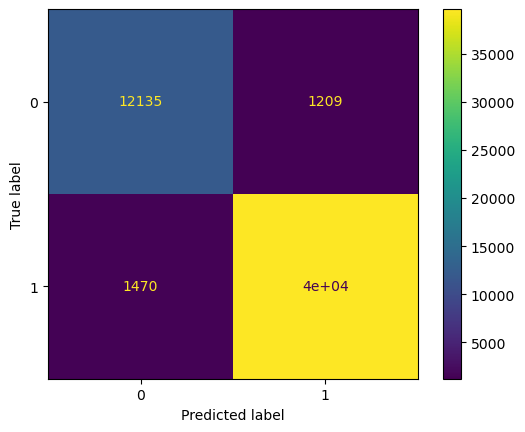

------------------------------
Model: HistGradientBoostingClassifier 

              precision    recall  f1-score   support

           0   0.891344  0.909847  0.900501     13344
           1   0.970553  0.964017  0.967274     41130

    accuracy                       0.950747     54474
   macro avg   0.930949  0.936932  0.933887     54474
weighted avg   0.951150  0.950747  0.950917     54474



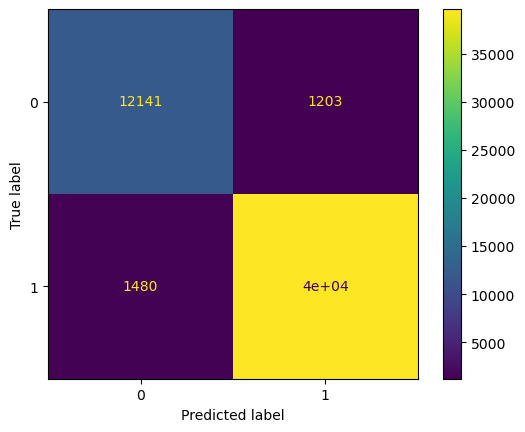

------------------------------
Model: XGBClassifier 

              precision    recall  f1-score   support

           0   0.891330  0.909098  0.900126     13344
           1   0.970316  0.964041  0.967168     41130

    accuracy                       0.950582     54474
   macro avg   0.930823  0.936569  0.933647     54474
weighted avg   0.950968  0.950582  0.950746     54474



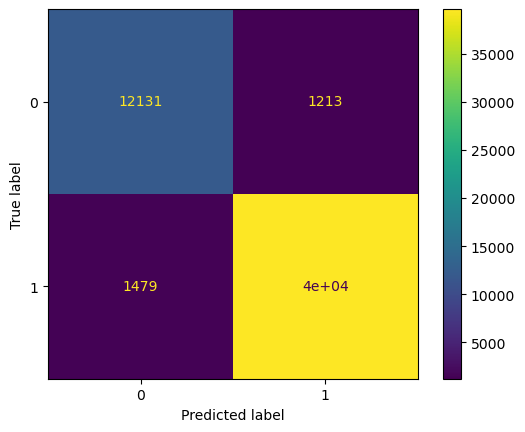

------------------------------
Model: MLPClassifier 

              precision    recall  f1-score   support

           0   0.912645  0.888639  0.900482     13344
           1   0.964176  0.972405  0.968273     41130

    accuracy                       0.951885     54474
   macro avg   0.938411  0.930522  0.934378     54474
weighted avg   0.951553  0.951885  0.951667     54474



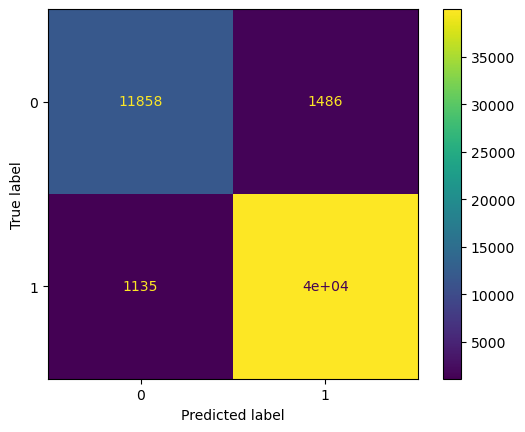

------------------------------
Model: LogisticRegression 

              precision    recall  f1-score   support

           0   0.893287  0.906475  0.899833     13344
           1   0.969511  0.964867  0.967184     41130

    accuracy                       0.950564     54474
   macro avg   0.931399  0.935671  0.933508     54474
weighted avg   0.950839  0.950564  0.950685     54474



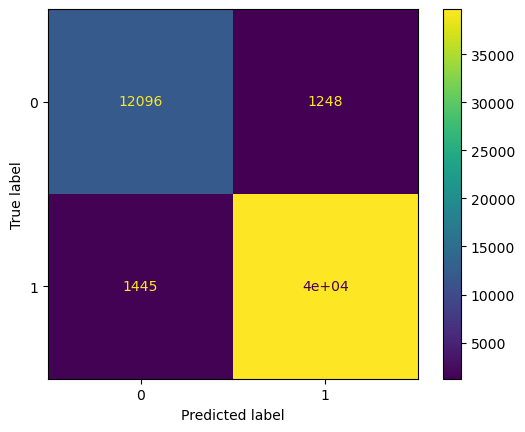

------------------------------
Model: GaussianNB 

              precision    recall  f1-score   support

           0   0.896395  0.901903  0.899141     13344
           1   0.968111  0.966180  0.967144     41130

    accuracy                       0.950435     54474
   macro avg   0.932253  0.934042  0.933143     54474
weighted avg   0.950543  0.950435  0.950486     54474



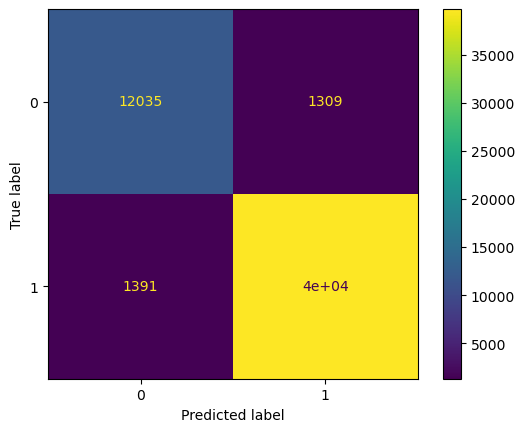

In [43]:
score_list = []

for model_name in ["LGBMClassifier", "HistGradientBoostingClassifier", "XGBClassifier",
                  "MLPClassifier", "LogisticRegression", "GaussianNB"]:

    param = results_df[results_df["model"] == model_name]["best_params"].iloc[0].copy()
    param = clean_param_extension(param)
    
    if model_name == "MLPClassifier":
        param["hidden_layer_sizes"] =  []
        nth_layer = 1
        while nth_layer <= param["num_layers"]:
            param["hidden_layer_sizes"].append(param.pop(f"num_perceptron_layer{nth_layer}"))
            nth_layer += 1
        del param["num_layers"]

    elif model_name in ["HistGradientBoostingClassifier", "LogisticRegression"]:
        class_weight_positive = param["class_weight_positive"] # scale_pos_weight
        param["class_weight"] = {0 : 1, 1 : class_weight_positive}
        del param["class_weight_positive"]   
    
    X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, 
                                               y_train, test_size = 0.1, stratify = y_train, random_state = 8) # just split once for val
    
    if model_name == "XGBClassifier": # no scaling needed
        dtrain = xgb.DMatrix(X_train_fold, label = y_train_fold)
        dval_train = xgb.DMatrix(X_val_fold, label = y_val_fold)
        dval = xgb.DMatrix(X_val)
        classifier = xgb.train(param,
            dtrain,
            num_boost_round = 2000,
            early_stopping_rounds = 30,
            evals = [(dval_train, "val")],
            verbose_eval = False
        )
        y_pred = (classifier.predict(dval) >= 0.45).astype(int) # 0.5 threshold, binary class 
        y_pred_proba = classifier.predict(dval)
#        explainer = shap.TreeExplainer(classifier, feature_names = ["knn_distance_mean", "knn_distance_std",
#                                                                               "knn_target_encoded_mean", "knn_target_encoded_std",
#                                                                               "positive_words_count", "negative_words_count",
#                                                                               "author_playtime_at_review", "votes_up", "votes_funny"])
#        shap_values = explainer(X_train)
    
    elif model_name == "LGBMClassifier": # no scaling needed
        dtrain = lgbm.Dataset(X_train_fold, label = y_train_fold)
        dval_train = lgbm.Dataset(X_val_fold, label = y_val_fold, reference = dtrain)
        classifier = lgbm.train(param,
            dtrain,
            num_boost_round = 2000,                         
            valid_sets = [dval_train],
            callbacks = [lgbm.early_stopping(stopping_rounds = 30, verbose = False),
                         lgbm.log_evaluation(period = -1)]
        )
        y_pred = (classifier.predict(X_val) >= 0.45).astype(int) # 0.5 threshold, binary class 
        y_pred_proba = classifier.predict(X_val)
#        explainer = shap.TreeExplainer(lgbm_classifier, feature_names = ["knn_distance_mean", "knn_distance_std",
#                                                                               "knn_target_encoded_mean", "knn_target_encoded_std",
#                                                                               "positive_words_count", "negative_words_count",
#                                                                               "author_playtime_at_review", "votes_up", "votes_funny"])
#        shap_values = explainer(X_train)
    
    else:
        pipeline = Pipeline([
            ("scale_extra_features", scale_extra_features), # HistGradientBoostingClassifier need no scaling, but cannot fit eval_set
            ("classifier", globals()[model_name](**param)) 
        ])
        pipeline.fit(X_train, y_train)
        #y_pred = pipeline.predict(X_val)
        y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
        y_pred = (y_pred_proba >= 0.45).astype(int)


    f1_score_val = f1_score(y_val, y_pred, average = "macro")
    accuracy_score_val = accuracy_score(y_val, y_pred)
    score_list.append({
        "model": model_name,
        "macro f1 score - val": f1_score_val,
        "accuracy score - val": accuracy_score_val
    })

    score_val_df = pd.DataFrame(score_list).sort_values(by = "macro f1 score - val", ascending = False).reset_index(drop = True)

    print("-" * 30)
    print(f"Model: {model_name} \n")
    print(classification_report(y_val, y_pred, digits = 6))
    cm_val = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm_val, display_labels = np.unique(y_val).tolist()).plot()
#    PrecisionRecallDisplay.from_predictions(y_val, y_pred_proba, name = f"{model_name}", despine = "True")
    plt.show()

#    if model_name in ["XGBClassifier", "LGBMClassifier"]:
#        shap.plots.beeswarm(shap_values)
#        del shap_values, explainer

Since there is still a prevalence of false negatives despite the increased performance of the models, we lowered the threshold to 45%.

**All the <u>adjusted models maintained performance at 93.3% - 93.5%</u> with marginal effects by adjusting the weights.**

## Test Results - BGE-small engineered features only

In [45]:
X_test = np.load("X_test_embeddings.npy", mmap_mode = "r")
y_test = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_test"]

X_test_extra_features_only = np.load("train_test_bge_m3.npz", mmap_mode = "r")["X_test"]
X_test_extra_features_only = X_test_extra_features_only[: ,-3:]

y_train = np.load("train_test_bge_m3.npz", mmap_mode = "r")["y_train"]

In [44]:
test_knn_indices, test_knn_distances = HNSW_query(X_test, 30, file_name = "train_bge_finetune")
np.savez("HNSW_results_BGE_M3_test.npz",
        test_knn_indices = test_knn_indices,
        test_knn_distances = test_knn_distances)

Normalizing X_embedding is finished! 

Batch 0 - 10000 start...
Done querying!
Batch 10000 - 20000 start...
Done querying!
Batch 20000 - 30000 start...
Done querying!
Batch 30000 - 40000 start...
Done querying!
Batch 40000 - 50000 start...
Done querying!
Batch 50000 - 54475 start...
Done querying!

 Finished creating indices and distances!


In [57]:
test_knn_distances = np.load("HNSW_results_BGE_M3_test.npz", mmap_mode = "r")["test_knn_distances"]
test_knn_indices = np.load("HNSW_results_BGE_M3_test.npz", mmap_mode = "r")["test_knn_indices"]

In [46]:
test_knn_mean_distances = test_knn_distances.mean(axis = 1) # how tight the neighborhood is (bigger implies being an outlier review)
test_knn_std_distances = test_knn_distances.std(axis = 1) # how consistent the review is with its neighbors (bigger implies inconsistency)
test_knn_target_encoding_mean = (y_train[test_knn_indices]).mean(axis = 1) # y_train data only, check the average sentiment of the neighborhood (higher implies positive)
test_knn_target_encoding_std = y_train[test_knn_indices].std(axis = 1) # y_train data only, check the sentiment consistency of the neighborhood

In [47]:
review_text_resampled = pd.read_parquet("review_text_resampled.parquet")

In [48]:
test_idx = np.load("split_indices.npz")["test_idx"]

In [49]:
test_review_text = review_text_resampled.iloc[test_idx][["review_text", "voted_up"]].copy()
test_review_text.to_parquet("test_review_text.parquet")
test_review_text.head()

,review_text,voted_up
276880,Only mapmaker I've used as professional gamema...,True
73877,"Nice, simple, and fun!\n\nThe artwork is great...",True
536067,The combat mechanics have no weight. The hub w...,False
457284,This game would've been nice if it had some or...,False
307456,"About Hepta Beats.\nIt is an incredible game, ...",True


In [50]:
test_review_text = pd.read_parquet("test_review_text.parquet")
test_review_text_corpus = test_review_text.copy()
del test_review_text
test_review_text_corpus.reset_index(drop = True, inplace = True)
gc.collect()

44450

In [51]:
tf_matrix_all = tf_by_batch(test_review_text_corpus["review_text"])
tf_matrix_all.shape

(54475, 89091)

In [52]:
top_positive_idx_filtered = np.load("train_filtered_top_words.npz")["top_positive_idx_filtered"]
top_negative_idx_filtered = np.load("train_filtered_top_words.npz")["top_negative_idx_filtered"]

test_positive_words_count = np.asarray(tf_matrix_all[ : , top_positive_idx_filtered].sum(axis=1)).flatten()
test_negative_words_count = np.asarray(tf_matrix_all[ : , top_negative_idx_filtered].sum(axis=1)).flatten()

In [53]:
test_positive_words_count.shape

(54475,)

In [87]:
np.savez("test_c_tfidf_results.npz",
        test_positive_words_count = test_positive_words_count,
        test_negative_words_count = test_negative_words_count)

In [54]:
X_test_engineered_features = np.empty((test_knn_distances.shape[0], 9), # keep only the engineered columns
                                      dtype = test_knn_distances.dtype)

In [55]:
X_test_engineered_features[:, 0] = test_knn_mean_distances
X_test_engineered_features[:, 1] = test_knn_std_distances
X_test_engineered_features[:, 2] = test_knn_target_encoding_mean 
X_test_engineered_features[:, 3] = test_knn_target_encoding_std
X_test_engineered_features[:, 4] = test_positive_words_count
X_test_engineered_features[:, 5] = test_negative_words_count
X_test_engineered_features[:, 6:] = X_test_extra_features_only


X_test_engineered_features.shape

(54475, 9)

In [56]:
X_train = np.load("X_train_engineered_features_BGE_finetuned.npy")

In [57]:
np.save("X_test_engineered_features.npy", X_test_engineered_features)
X_test = X_test_engineered_features.copy() # renaming for convention

In [58]:
analysis_df = pd.read_parquet("review_text_resampled.parquet") # for analysis of errors
analysis_df = analysis_df.iloc[test_idx]

------------------------------
Model: LGBMClassifier 

              precision    recall  f1-score   support

           0   0.893249  0.909179  0.901144     13345
           1   0.970361  0.964746  0.967545     41130

    accuracy                       0.951134     54475
   macro avg   0.931805  0.936963  0.934345     54475
weighted avg   0.951470  0.951134  0.951279     54475



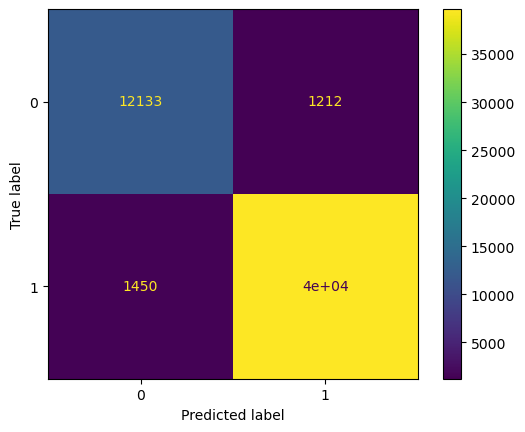

------------------------------
Model: HistGradientBoostingClassifier 

              precision    recall  f1-score   support

           0   0.892112  0.910229  0.901079     13345
           1   0.970680  0.964284  0.967471     41130

    accuracy                       0.951042     54475
   macro avg   0.931396  0.937256  0.934275     54475
weighted avg   0.951433  0.951042  0.951207     54475



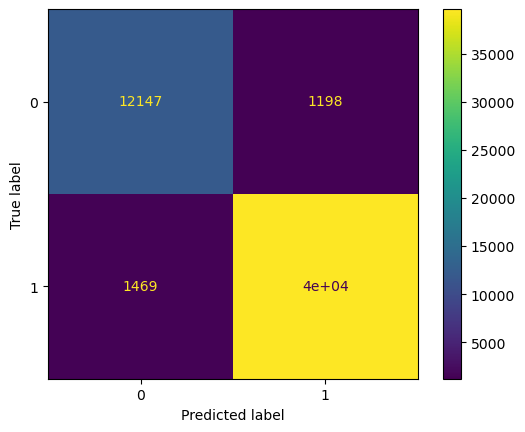

------------------------------
Model: XGBClassifier 

              precision    recall  f1-score   support

           0   0.892466  0.909854  0.901076     13345
           1   0.970565  0.964430  0.967488     41130

    accuracy                       0.951060     54475
   macro avg   0.931516  0.937142  0.934282     54475
weighted avg   0.951433  0.951060  0.951219     54475



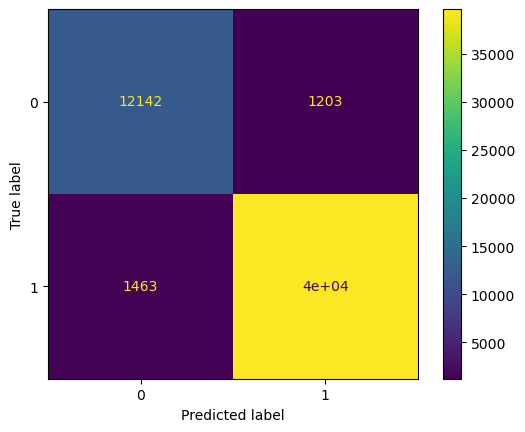

------------------------------
Model: MLPClassifier 

              precision    recall  f1-score   support

           0   0.914021  0.886624  0.900114     13345
           1   0.963569  0.972939  0.968231     41130

    accuracy                       0.951794     54475
   macro avg   0.938795  0.929782  0.934173     54475
weighted avg   0.951431  0.951794  0.951544     54475



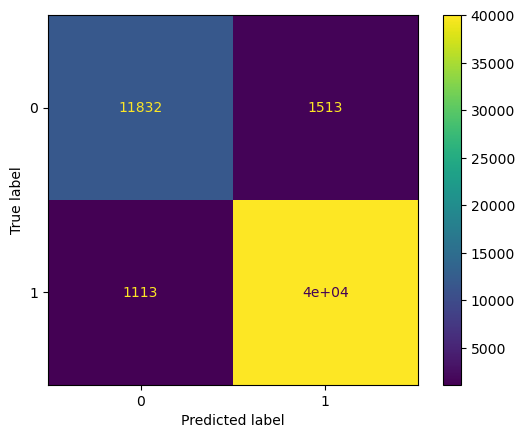

------------------------------
Model: LogisticRegression 

              precision    recall  f1-score   support

           0   0.895538  0.908355  0.901901     13345
           1   0.970126  0.965621  0.967869     41130

    accuracy                       0.951592     54475
   macro avg   0.932832  0.936988  0.934885     54475
weighted avg   0.951854  0.951592  0.951708     54475



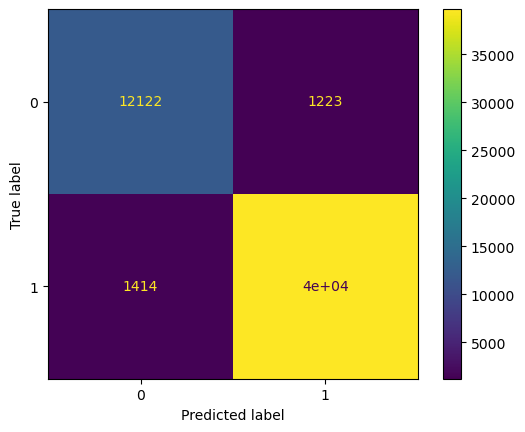

------------------------------
Model: GaussianNB 

              precision    recall  f1-score   support

           0   0.898167  0.903484  0.900818     13345
           1   0.968624  0.966764  0.967693     41130

    accuracy                       0.951262     54475
   macro avg   0.933396  0.935124  0.934256     54475
weighted avg   0.951364  0.951262  0.951311     54475



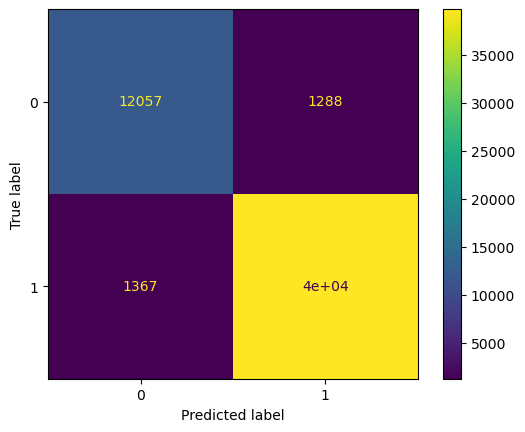

In [59]:
score_list = []

for model_name in ["LGBMClassifier", "HistGradientBoostingClassifier", "XGBClassifier",
                  "MLPClassifier", "LogisticRegression", "GaussianNB"]:

    param = results_df[results_df["model"] == model_name]["best_params"].iloc[0].copy()
    param = clean_param_extension(param)
    
    if model_name == "MLPClassifier":
        param["hidden_layer_sizes"] =  []
        nth_layer = 1
        while nth_layer <= param["num_layers"]:
            param["hidden_layer_sizes"].append(param.pop(f"num_perceptron_layer{nth_layer}"))
            nth_layer += 1
        del param["num_layers"]

    elif model_name in ["HistGradientBoostingClassifier", "LogisticRegression"]:
        class_weight_positive = param["class_weight_positive"] # scale_pos_weight
        param["class_weight"] = {0 : 1, 1 : class_weight_positive}
        del param["class_weight_positive"]   
    
    X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, 
                                               y_train, test_size = 0.1, stratify = y_train, random_state = 8) # just split once for val
    
    if model_name == "XGBClassifier": # no scaling needed
        dtrain = xgb.DMatrix(X_train_fold, label = y_train_fold)
        dval_train = xgb.DMatrix(X_val_fold, label = y_val_fold)
        dtest = xgb.DMatrix(X_test)
        classifier = xgb.train(param,
            dtrain,
            num_boost_round = 1000,
            early_stopping_rounds = 30,
            evals = [(dval_train, "val")],
            verbose_eval = False
        )
        y_pred = (classifier.predict(dtest) >= 0.45).astype(int) # 0.5 threshold, binary class 
        y_pred_proba = classifier.predict(dtest)
#        explainer = shap.TreeExplainer(classifier, feature_names = ["knn_distance_mean", "knn_distance_std",
#                                                                               "knn_target_encoded_mean", "knn_target_encoded_std",
#                                                                               "positive_words_count", "negative_words_count",
#                                                                               "author_playtime_at_review", "votes_up", "votes_funny"])
#        shap_values = explainer(X_train)
    
    elif model_name == "LGBMClassifier": # no scaling needed
        dtrain = lgbm.Dataset(X_train_fold, label = y_train_fold)
        dval_train = lgbm.Dataset(X_val_fold, label = y_val_fold, reference = dtrain)
        classifier = lgbm.train(param,
            dtrain,
            num_boost_round = 1000,                         
            valid_sets = [dval_train],
            callbacks = [lgbm.early_stopping(stopping_rounds = 30, verbose = False),
                         lgbm.log_evaluation(period = -1)]
        )
        y_pred = (classifier.predict(X_test) >= 0.45).astype(int) # 0.5 threshold, binary class 
        y_pred_proba = classifier.predict(X_test)
#        explainer = shap.TreeExplainer(lgbm_classifier, feature_names = ["knn_distance_mean", "knn_distance_std",
#                                                                               "knn_target_encoded_mean", "knn_target_encoded_std",
#                                                                               "positive_words_count", "negative_words_count",
#                                                                               "author_playtime_at_review", "votes_up", "votes_funny"])
#        shap_values = explainer(X_train)
    
    else:
        pipeline = Pipeline([
            ("scale_extra_features", scale_extra_features), # HistGradientBoostingClassifier need no scaling, but cannot fit eval_set
            ("classifier", globals()[model_name](**param)) 
        ])
        pipeline.fit(X_train, y_train)
        #y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_pred_proba >= 0.45).astype(int)

    f1_score_test = f1_score(y_test, y_pred, average = "macro")
    accuracy_score_test = accuracy_score(y_test, y_pred)
    score_list.append({
        "model": model_name,
        "macro f1 score - test": f1_score_test,
        "accuracy score - test": accuracy_score_test
    })

    analysis_df[f"y_pred_{model_name}"] = y_pred
    score_test_df = pd.DataFrame(score_list).sort_values(by = "macro f1 score - test", ascending = False).reset_index(drop = True)

    print("-" * 30)
    print(f"Model: {model_name} \n")
    print(classification_report(y_test, y_pred, digits = 6))
    cm_test = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm_test, display_labels = np.unique(y_test).tolist()).plot()
#    PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, name = f"{model_name}", despine = "True")
    plt.show()

#    if model_name in ["XGBClassifier", "LGBMClassifier"]:
#        shap.plots.beeswarm(shap_values)
#        del shap_values, explainer

In [60]:
score_test_df.to_parquet("score_test_df_BGE_small_finetuned.parquet")
print(score_test_df)

                            model  macro f1 score - test  \
0              LogisticRegression               0.934885   
1                  LGBMClassifier               0.934345   
2                   XGBClassifier               0.934282   
3  HistGradientBoostingClassifier               0.934275   
4                      GaussianNB               0.934256   
5                   MLPClassifier               0.934173   

   accuracy score - test  
0               0.951592  
1               0.951134  
2               0.951060  
3               0.951042  
4               0.951262  
5               0.951794  


In [61]:
analysis_df["voted_up"] = analysis_df["voted_up"].map({True : 1, False : 0})
analysis_df[analysis_df["voted_up"] != analysis_df["y_pred_LGBMClassifier"]]

,review_text,voted_up,y_pred_LGBMClassifier,y_pred_HistGradientBoostingClassifier,y_pred_XGBClassifier,y_pred_MLPClassifier,y_pred_LogisticRegression,y_pred_GaussianNB
288524,I suggest waiting for several graphic bugs to ...,0,1,1,1,1,1,1
447394,"Nice try, I like the gameplay, but there are b...",1,0,0,0,0,0,0
129813,This game is hard. I purchased it discounted w...,0,1,1,1,1,1,1
431530,It was scarey,0,1,1,1,1,1,1
77428,Reminiscent of Dark Star (1974) without humor ...,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
431455,Game is fun. Love to support EHG. One thing I ...,0,1,1,1,1,1,1
151579,It's a fun game with a clever fast-paced comba...,0,1,1,1,1,1,1
123162,from the past DLC from the gundam breaker seri...,0,1,1,1,1,1,1
458828,This pack has some awesome gear that being sai...,0,1,1,1,1,1,1


### Using SHAP on the best model

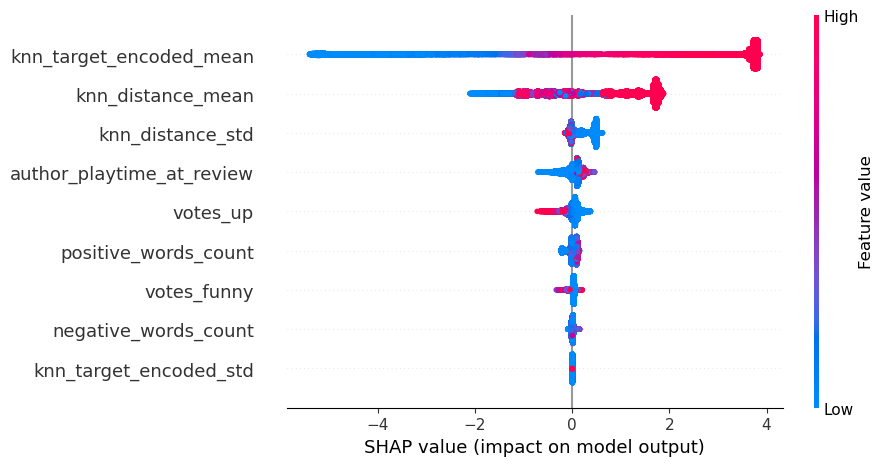

In [62]:
score_list = []

for model_name in ["XGBClassifier"]:

    param = results_df[results_df["model"] == model_name]["best_params"].iloc[0].copy()
    param = clean_param_extension(param)
    
    
    X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, 
                                               y_train, test_size = 0.1, stratify = y_train, random_state = 8) # just split once for val
    
    if model_name == "XGBClassifier": # no scaling needed
        dtrain = xgb.DMatrix(X_train_fold, label = y_train_fold)
        dval_train = xgb.DMatrix(X_val_fold, label = y_val_fold)
        dtest = xgb.DMatrix(X_test)
        classifier = xgb.train(param,
            dtrain,
            num_boost_round = 1000,
            early_stopping_rounds = 30,
            evals = [(dval_train, "val")],
            verbose_eval = False
        )
        y_pred = (classifier.predict(dtest) >= 0.45).astype(int) # 0.5 threshold, binary class 
#        y_pred_proba = classifier.predict(dtest)
        explainer = shap.TreeExplainer(classifier, feature_names = ["knn_distance_mean", "knn_distance_std",
                                                                               "knn_target_encoded_mean", "knn_target_encoded_std",
                                                                               "positive_words_count", "negative_words_count",
                                                                               "author_playtime_at_review", "votes_up", "votes_funny"])
        
        shap_values = explainer(X_test)
        shap.plots.beeswarm(shap_values)

## Conclusion

**Finetuning an embedding model on your specific domain will also capture the nuances of the training corpus. The embeddings already captured the amount of positive and negative words for each review as seen in the SHAP values, among others. This also shows that finetuning a smaller model to your domain produces better results than an out-of-the-bag embedding model.**

**LogisticRegression scored the highest with 93.4885% macro-averaged f1-score,  95.1708% weighted-averaged f1-score, and 95.1592% accuracy. Although for consistency in reference to the original project, XGBoostClassifier is preferred. There is not much difference in performance of the XGBoost model vs the Logistic Regression model.**

_More findings can be found in the written report._